# EDA

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

### 데이터 호출

In [154]:
_ROOT_DIR = "./../../"

In [155]:
# data call
def call_data():
    ret_df = pd.read_csv(_ROOT_DIR+ './data/raw/cell2celltrain.csv')

    return ret_df

In [156]:
df = call_data()

### Target인 churn만 1/0 변환

In [157]:
# Churn (Yes/No) -> 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### 데이터 기본정보 확인

In [158]:
def check_datas(df):
    print("------Head------")
    display(df.head())
    print("------Info------")
    display(df.info())
    print("------Describe------")
    display(df.describe())
    print("------중복값 확인------")
    print(df.duplicated().sum())

In [159]:
check_datas(df)

------Head------


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


------Info------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  int64  
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51

None

------Describe------


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,5.104700e+04,51047.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50680.000000,50680.000000,...,51046.000000,51046.000000,51046.000000,50138.000000,50138.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,3.201957e+06,0.288185,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,...,1.805646,1.558751,380.545841,31.338127,21.144142,0.037201,0.018277,0.052070,4.324524,0.053911
std,1.169056e+05,0.452922,44.507336,529.871063,23.848871,2.228546,96.588076,9.818294,257.514772,39.574915,...,1.331173,0.905932,253.801982,22.094635,23.931368,0.206483,0.142458,0.307592,3.138236,0.383147
min,3.000002e+06,0.000000,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.100632e+06,0.000000,33.610000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,...,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.201534e+06,0.000000,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,...,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,3.305376e+06,1.000000,71.065000,723.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,3.399994e+06,1.000000,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,...,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000


------중복값 확인------
0


### 결측치, 이상치 확인

In [160]:
df.isnull().sum().sort_values(ascending=False)

AgeHH1                       909
AgeHH2                       909
PercChangeRevenues           367
PercChangeMinutes            367
DirectorAssistedCalls        156
TotalRecurringCharge         156
RoamingCalls                 156
OverageMinutes               156
MonthlyRevenue               156
MonthlyMinutes               156
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
DroppedCalls                   0
BlockedCalls                   0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
Churn                          0
CustomerID                     0
ActiveSubs                     0
UniqueSubs                     0
MonthsInService                0
CallWaitingCalls               0
CallForwar

In [161]:
# 결측치를 하나라도 가지고 있는 행의 수
missing_rows = df.isnull().any(axis=1).sum()
total_rows = len(df)

ratio = (missing_rows / total_rows) * 100
print(f'결측치 비율: {ratio:.2f}%')

결측치 비율: 2.54%


### 수치형 데이터 체크 및 이상치 확인

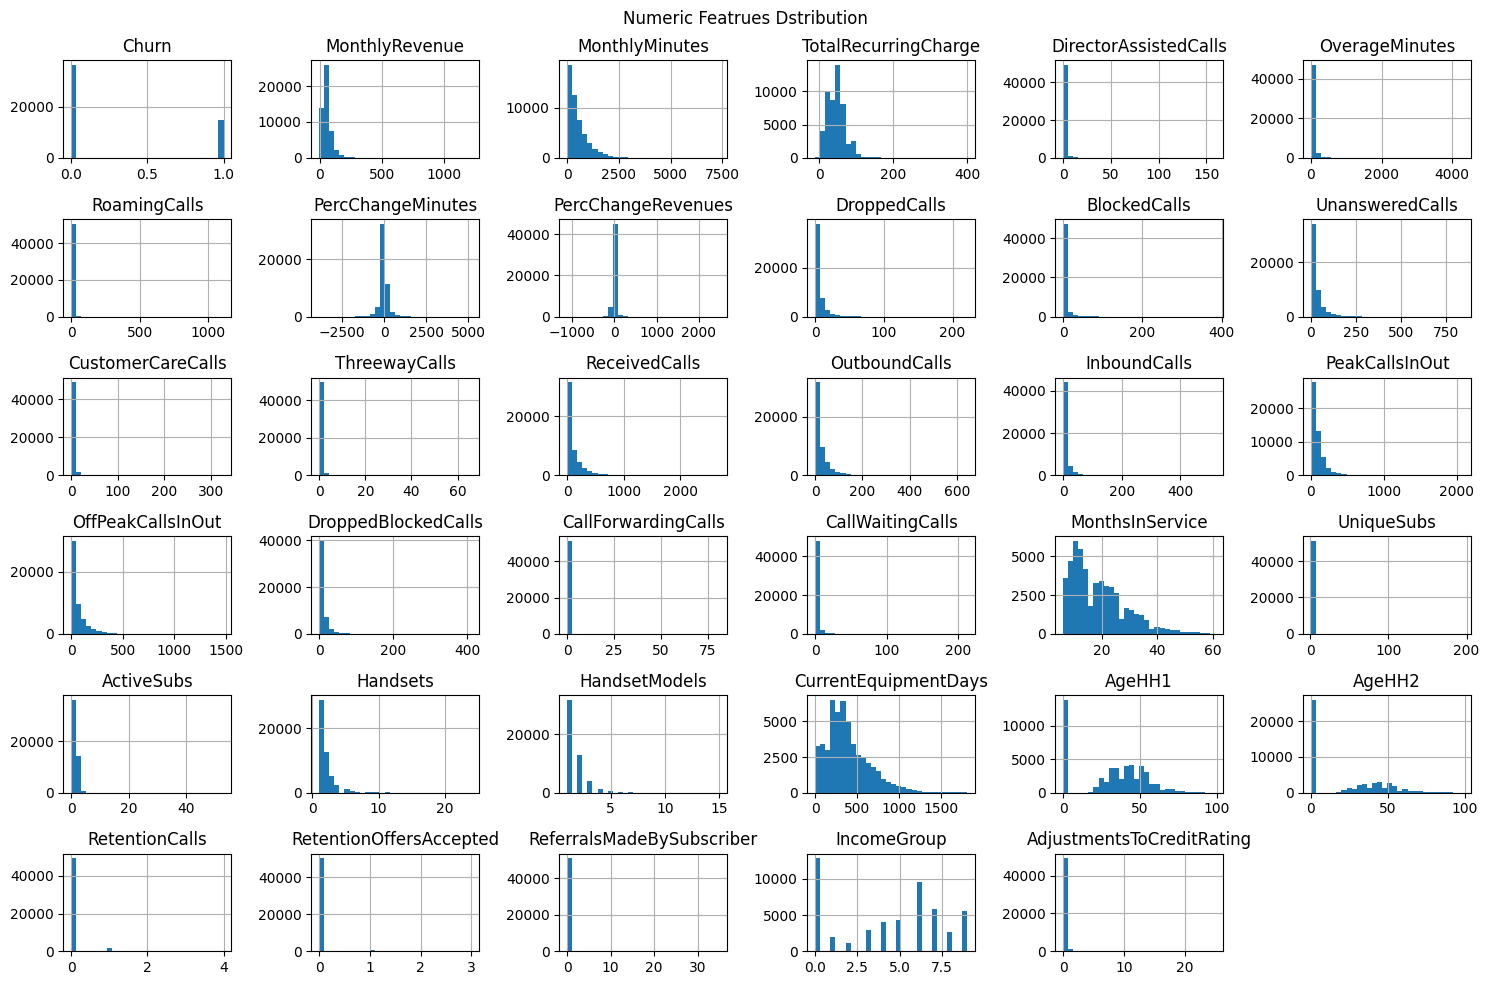

In [162]:
# 수치형 feature 히스토그램
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'CustomerID' in numeric_cols:
    numeric_cols.remove('CustomerID')

df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Numeric Featrues Dstribution')
plt.tight_layout()
plt.show()


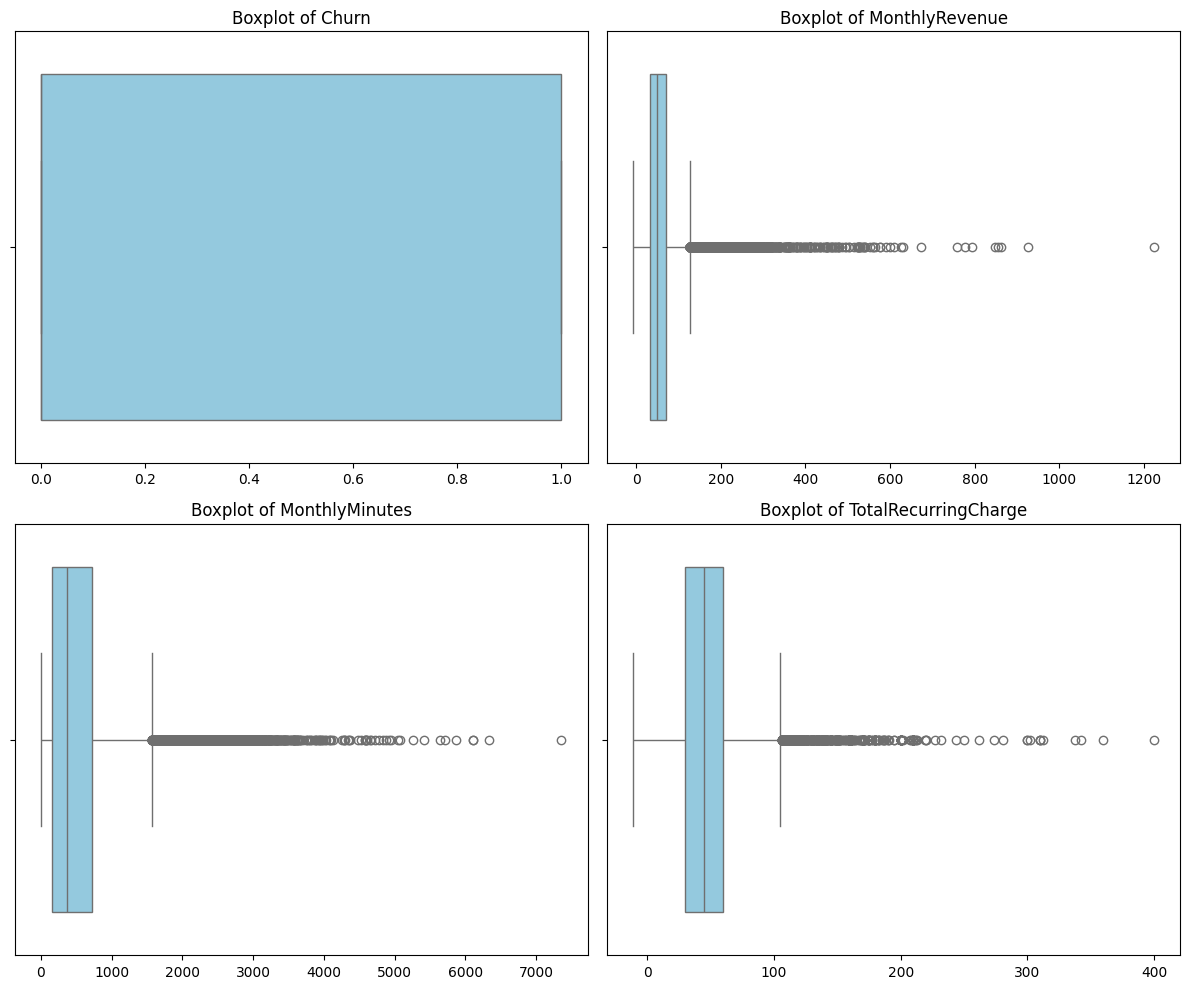

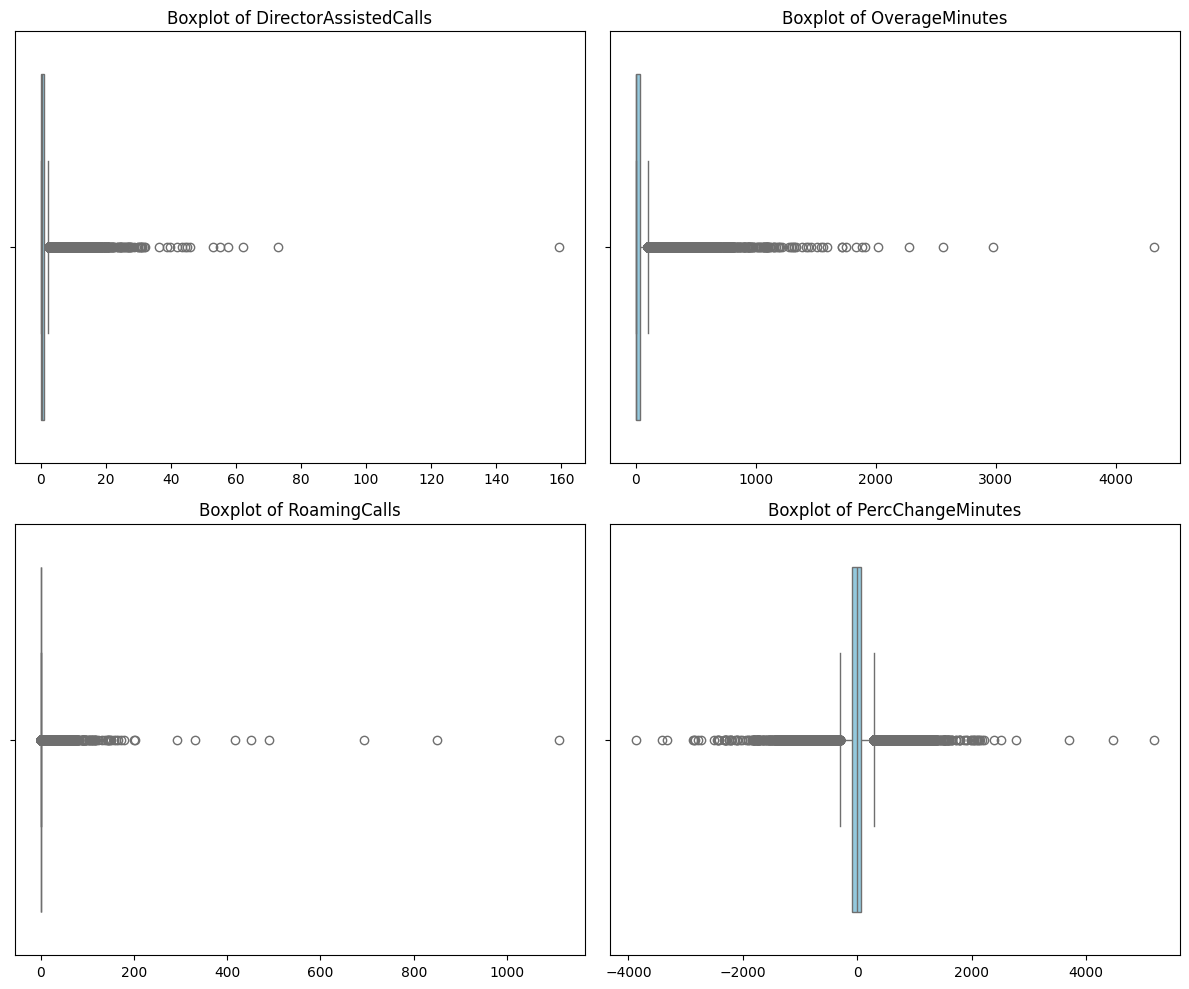

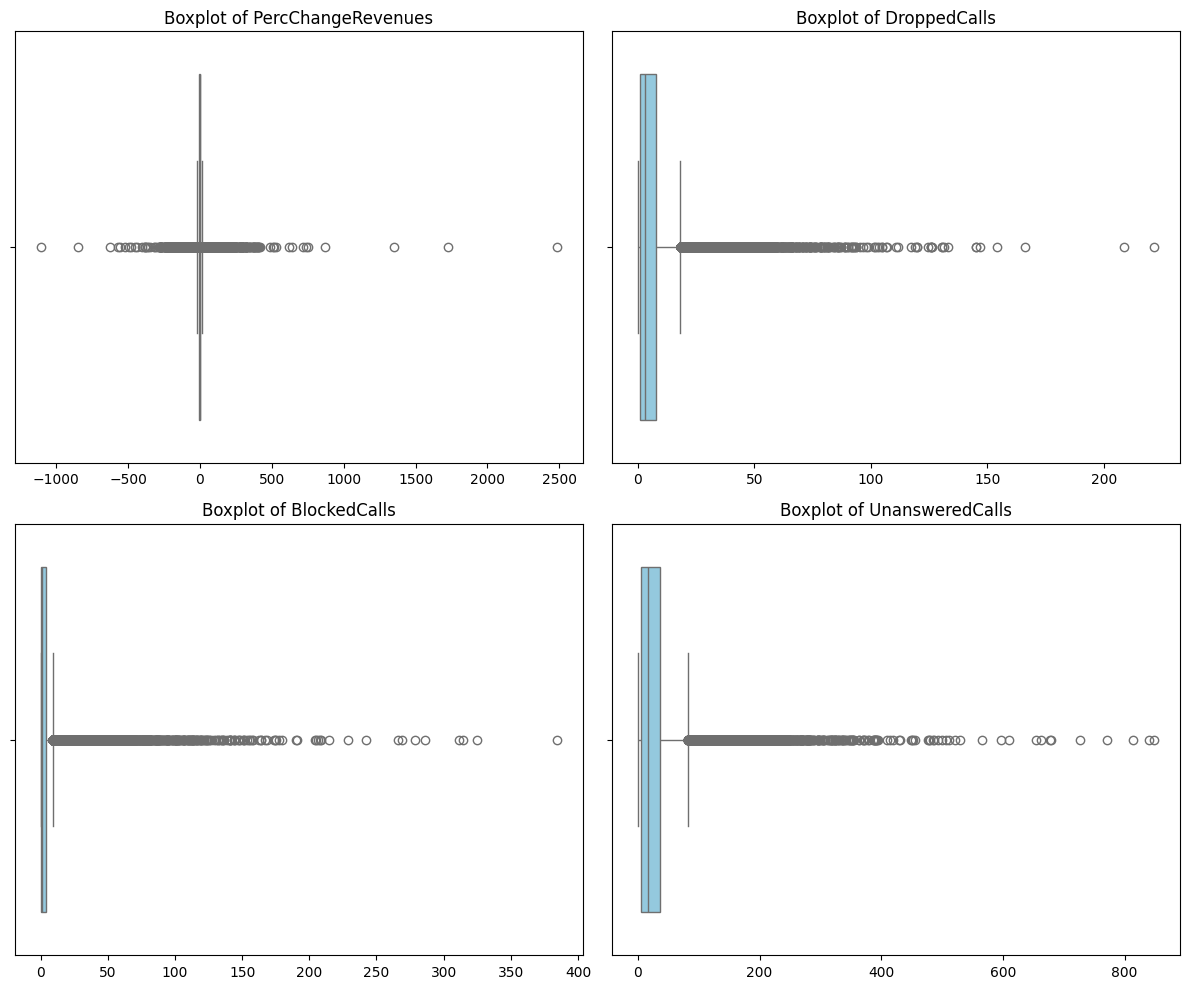

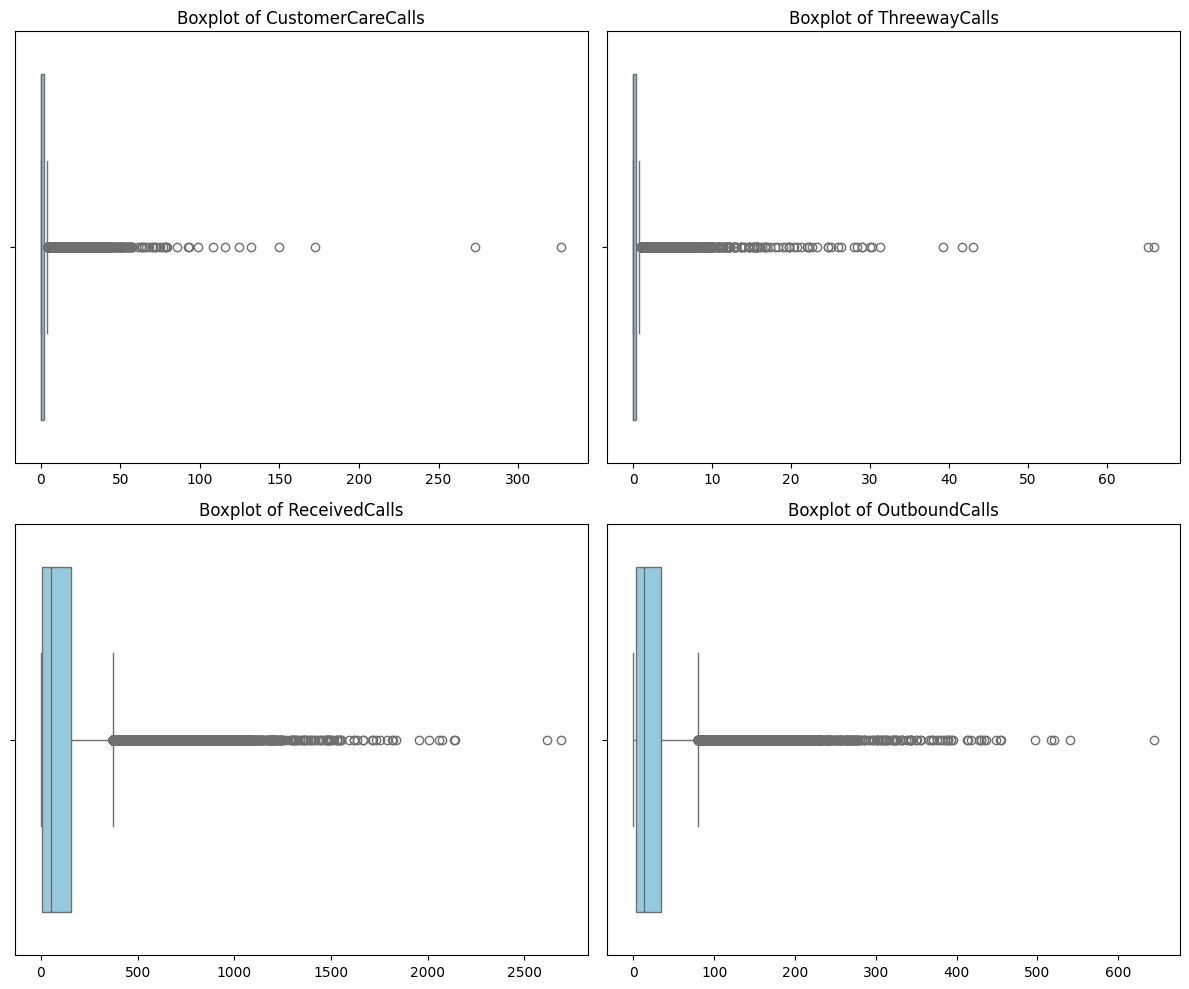

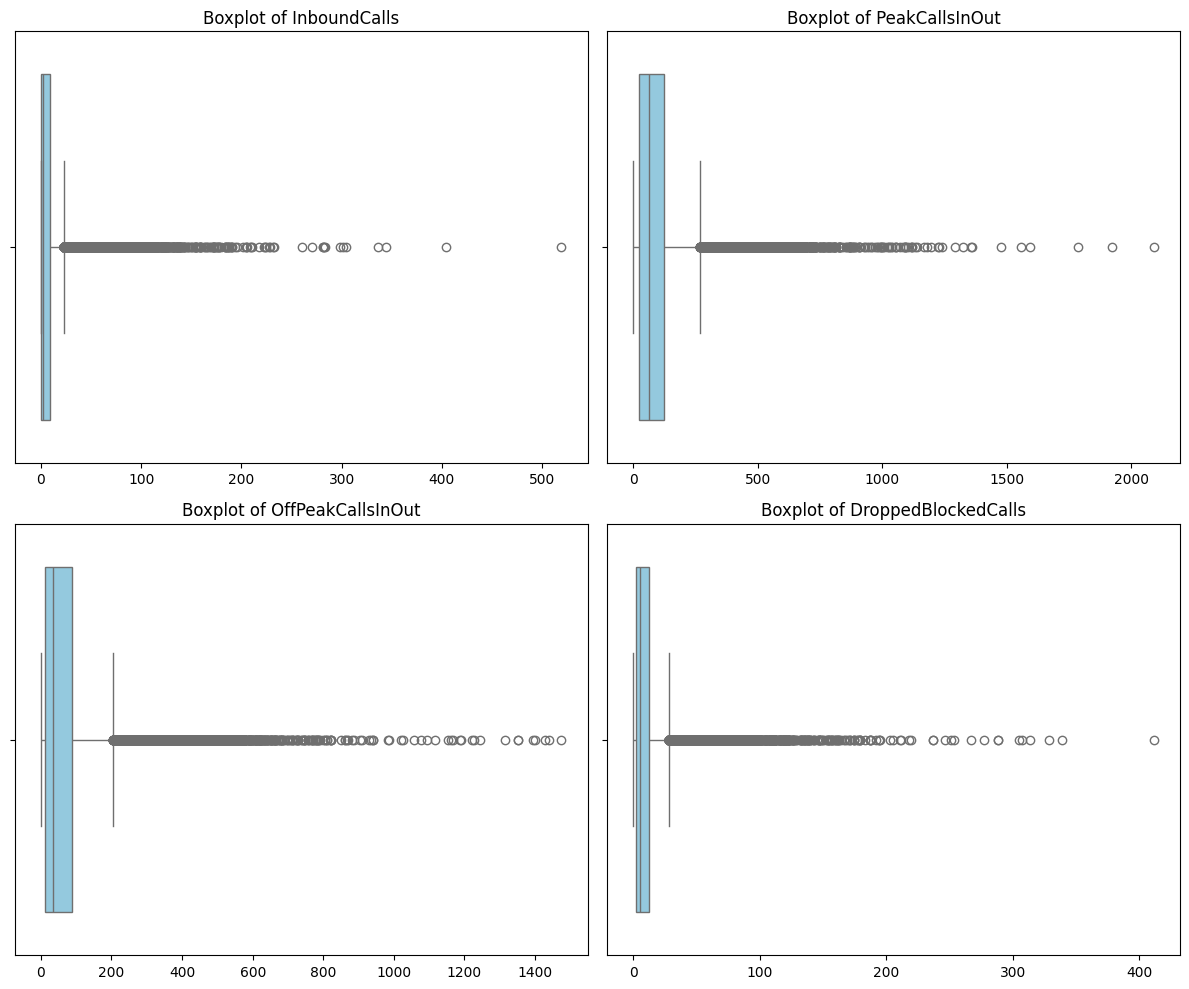

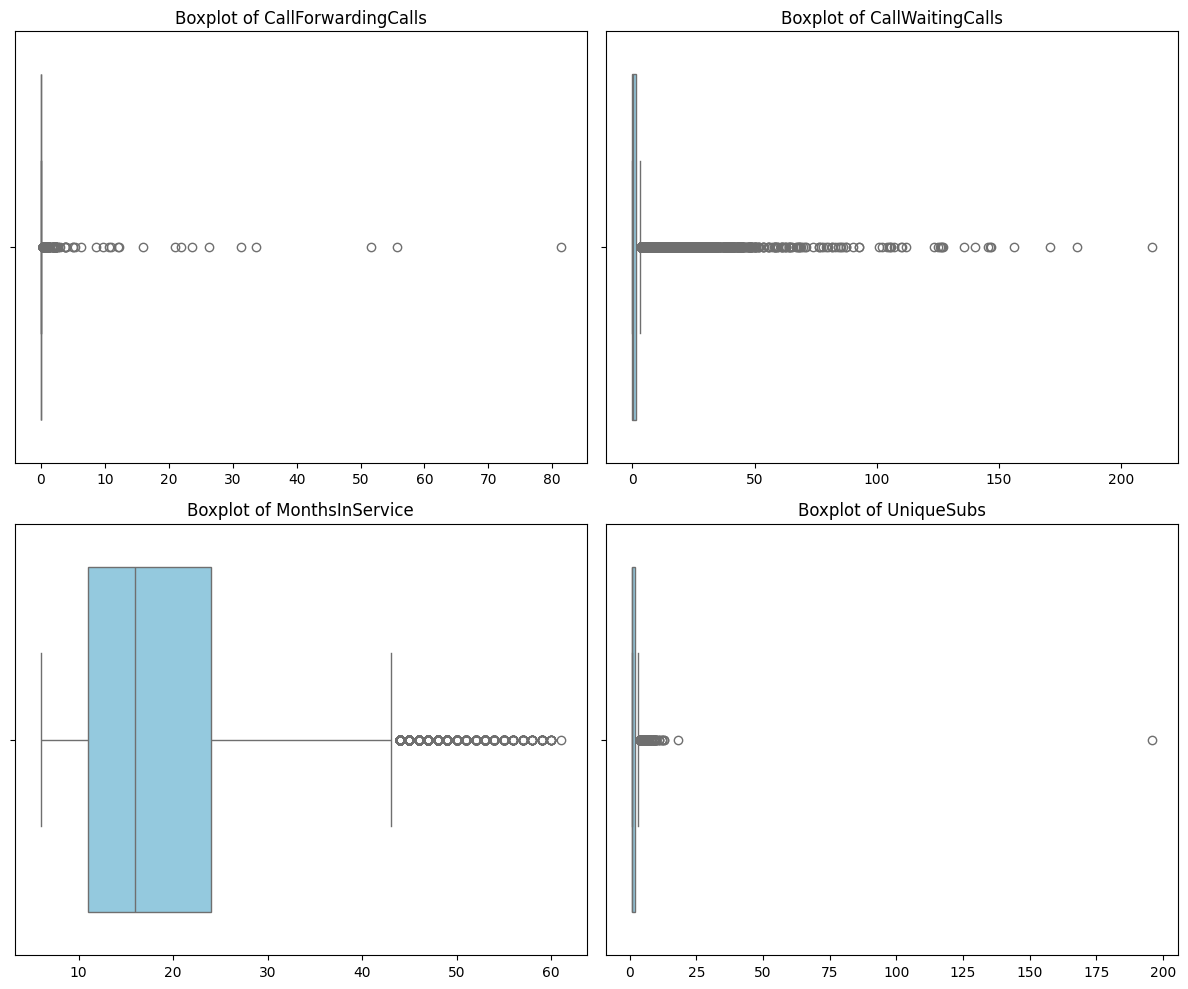

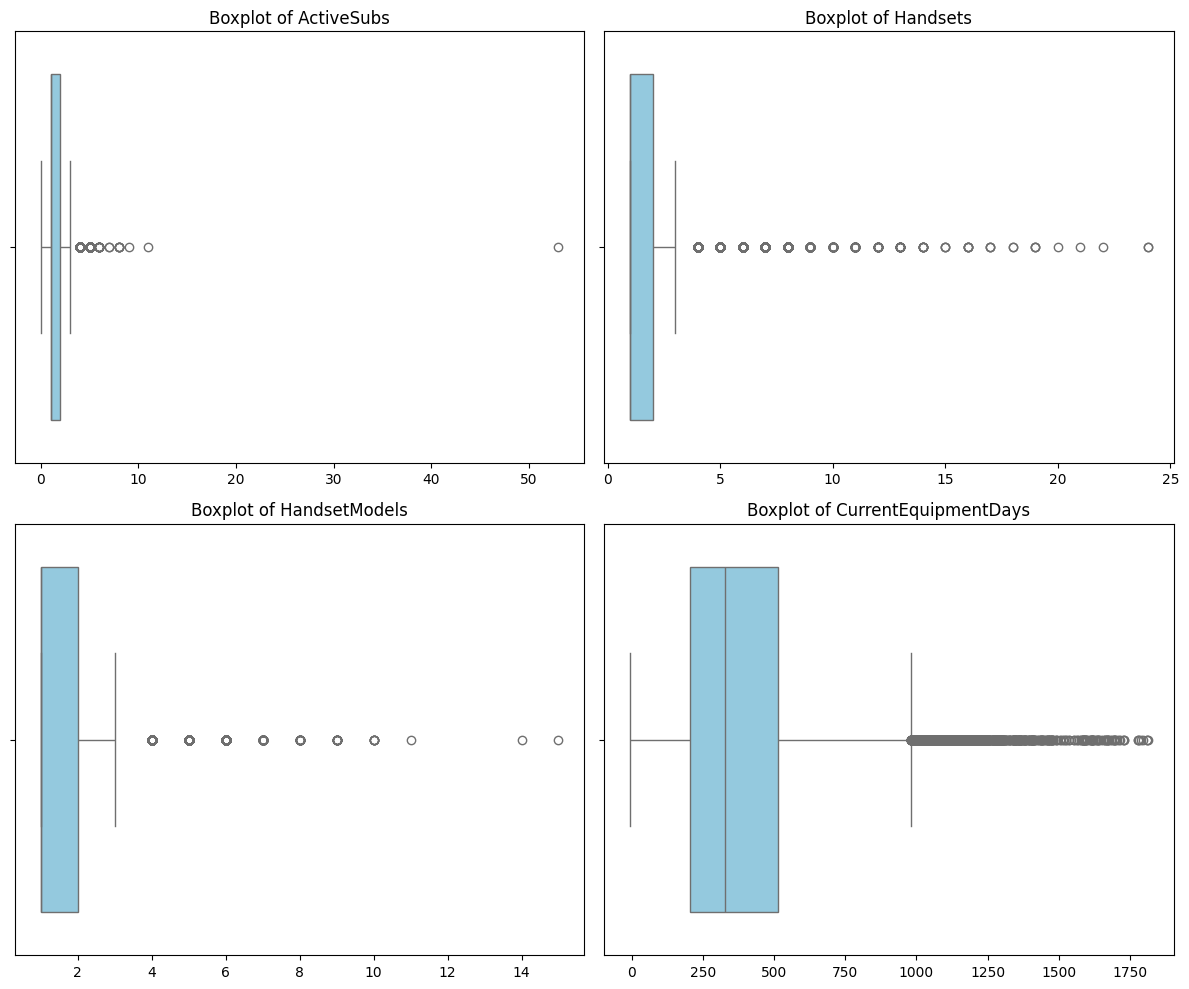

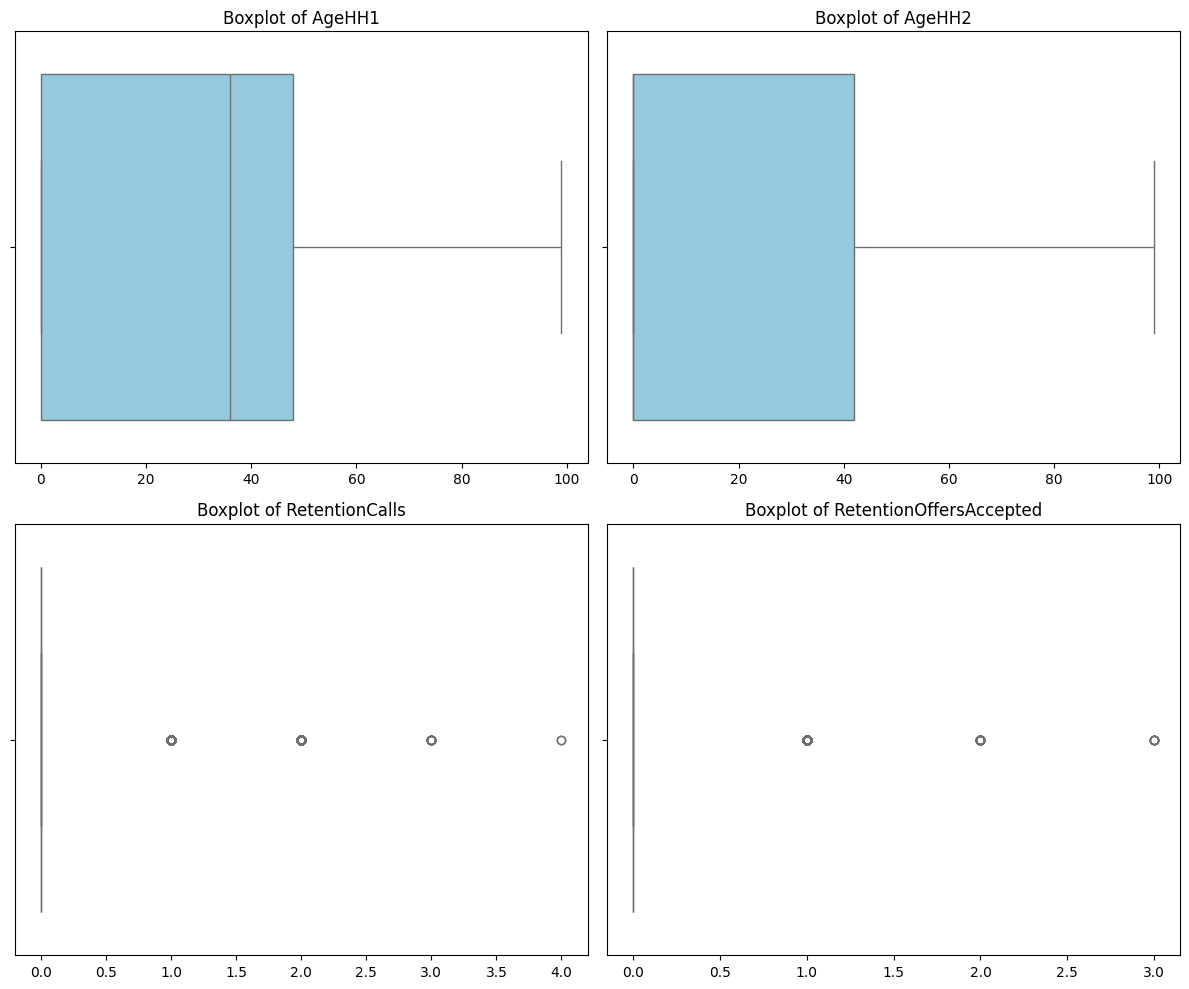

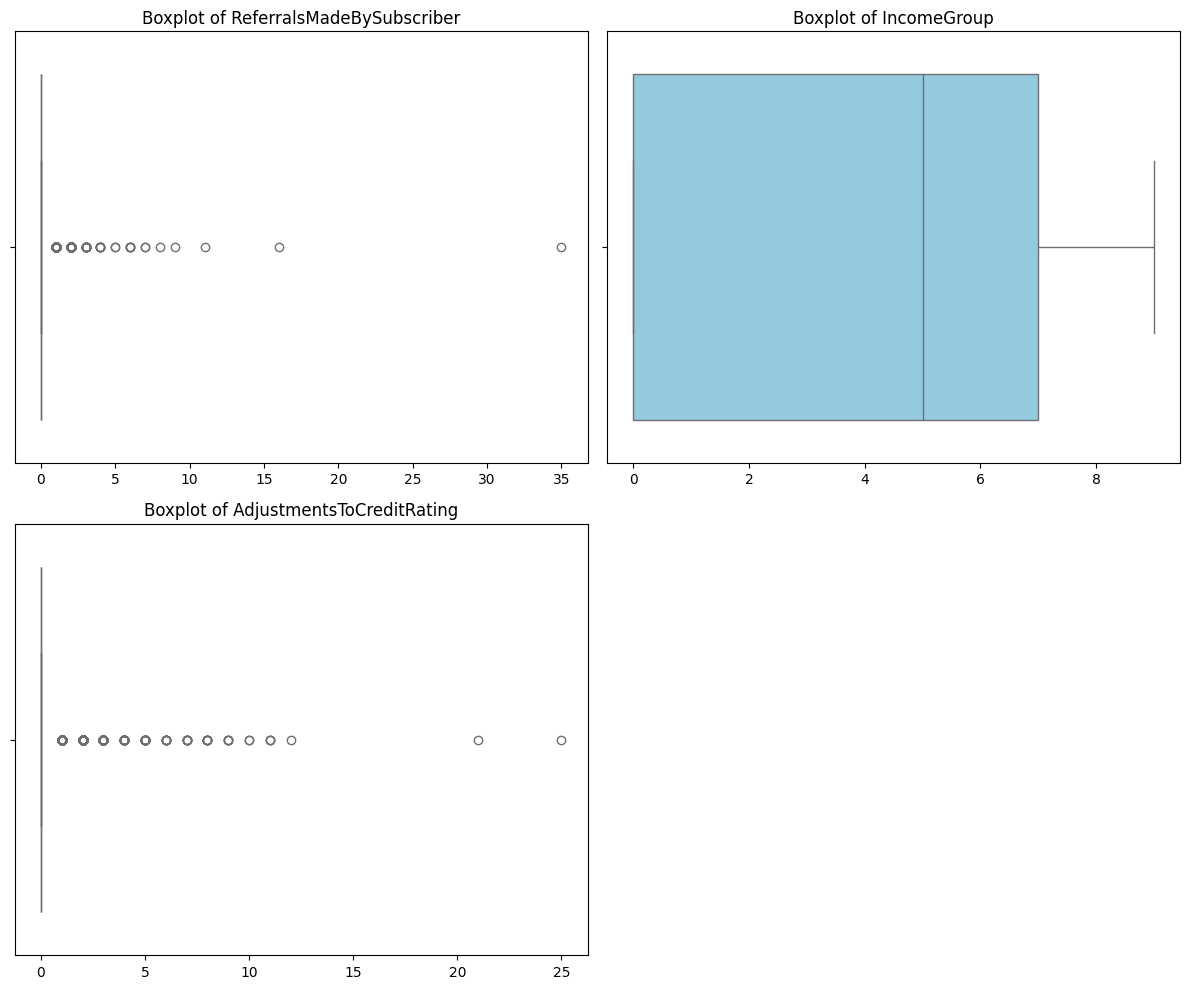

In [163]:
# Boxplot
n_cols = 2
n_rows = 2
items_per_page = n_cols * n_rows
num_pages = math.ceil(len(numeric_cols) / items_per_page)

for page in range(num_pages):
    plt.figure(figsize=(12, 10))
    start_idx = page * items_per_page
    end_idx = min(start_idx + items_per_page, len(numeric_cols))
    
    for i, col in enumerate(numeric_cols[start_idx:end_idx]):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f'Boxplot of {col}', fontsize=12)
        plt.xlabel('')
        
    plt.tight_layout()
    plt.show()    


### 수치형 변수 상관계수 계산

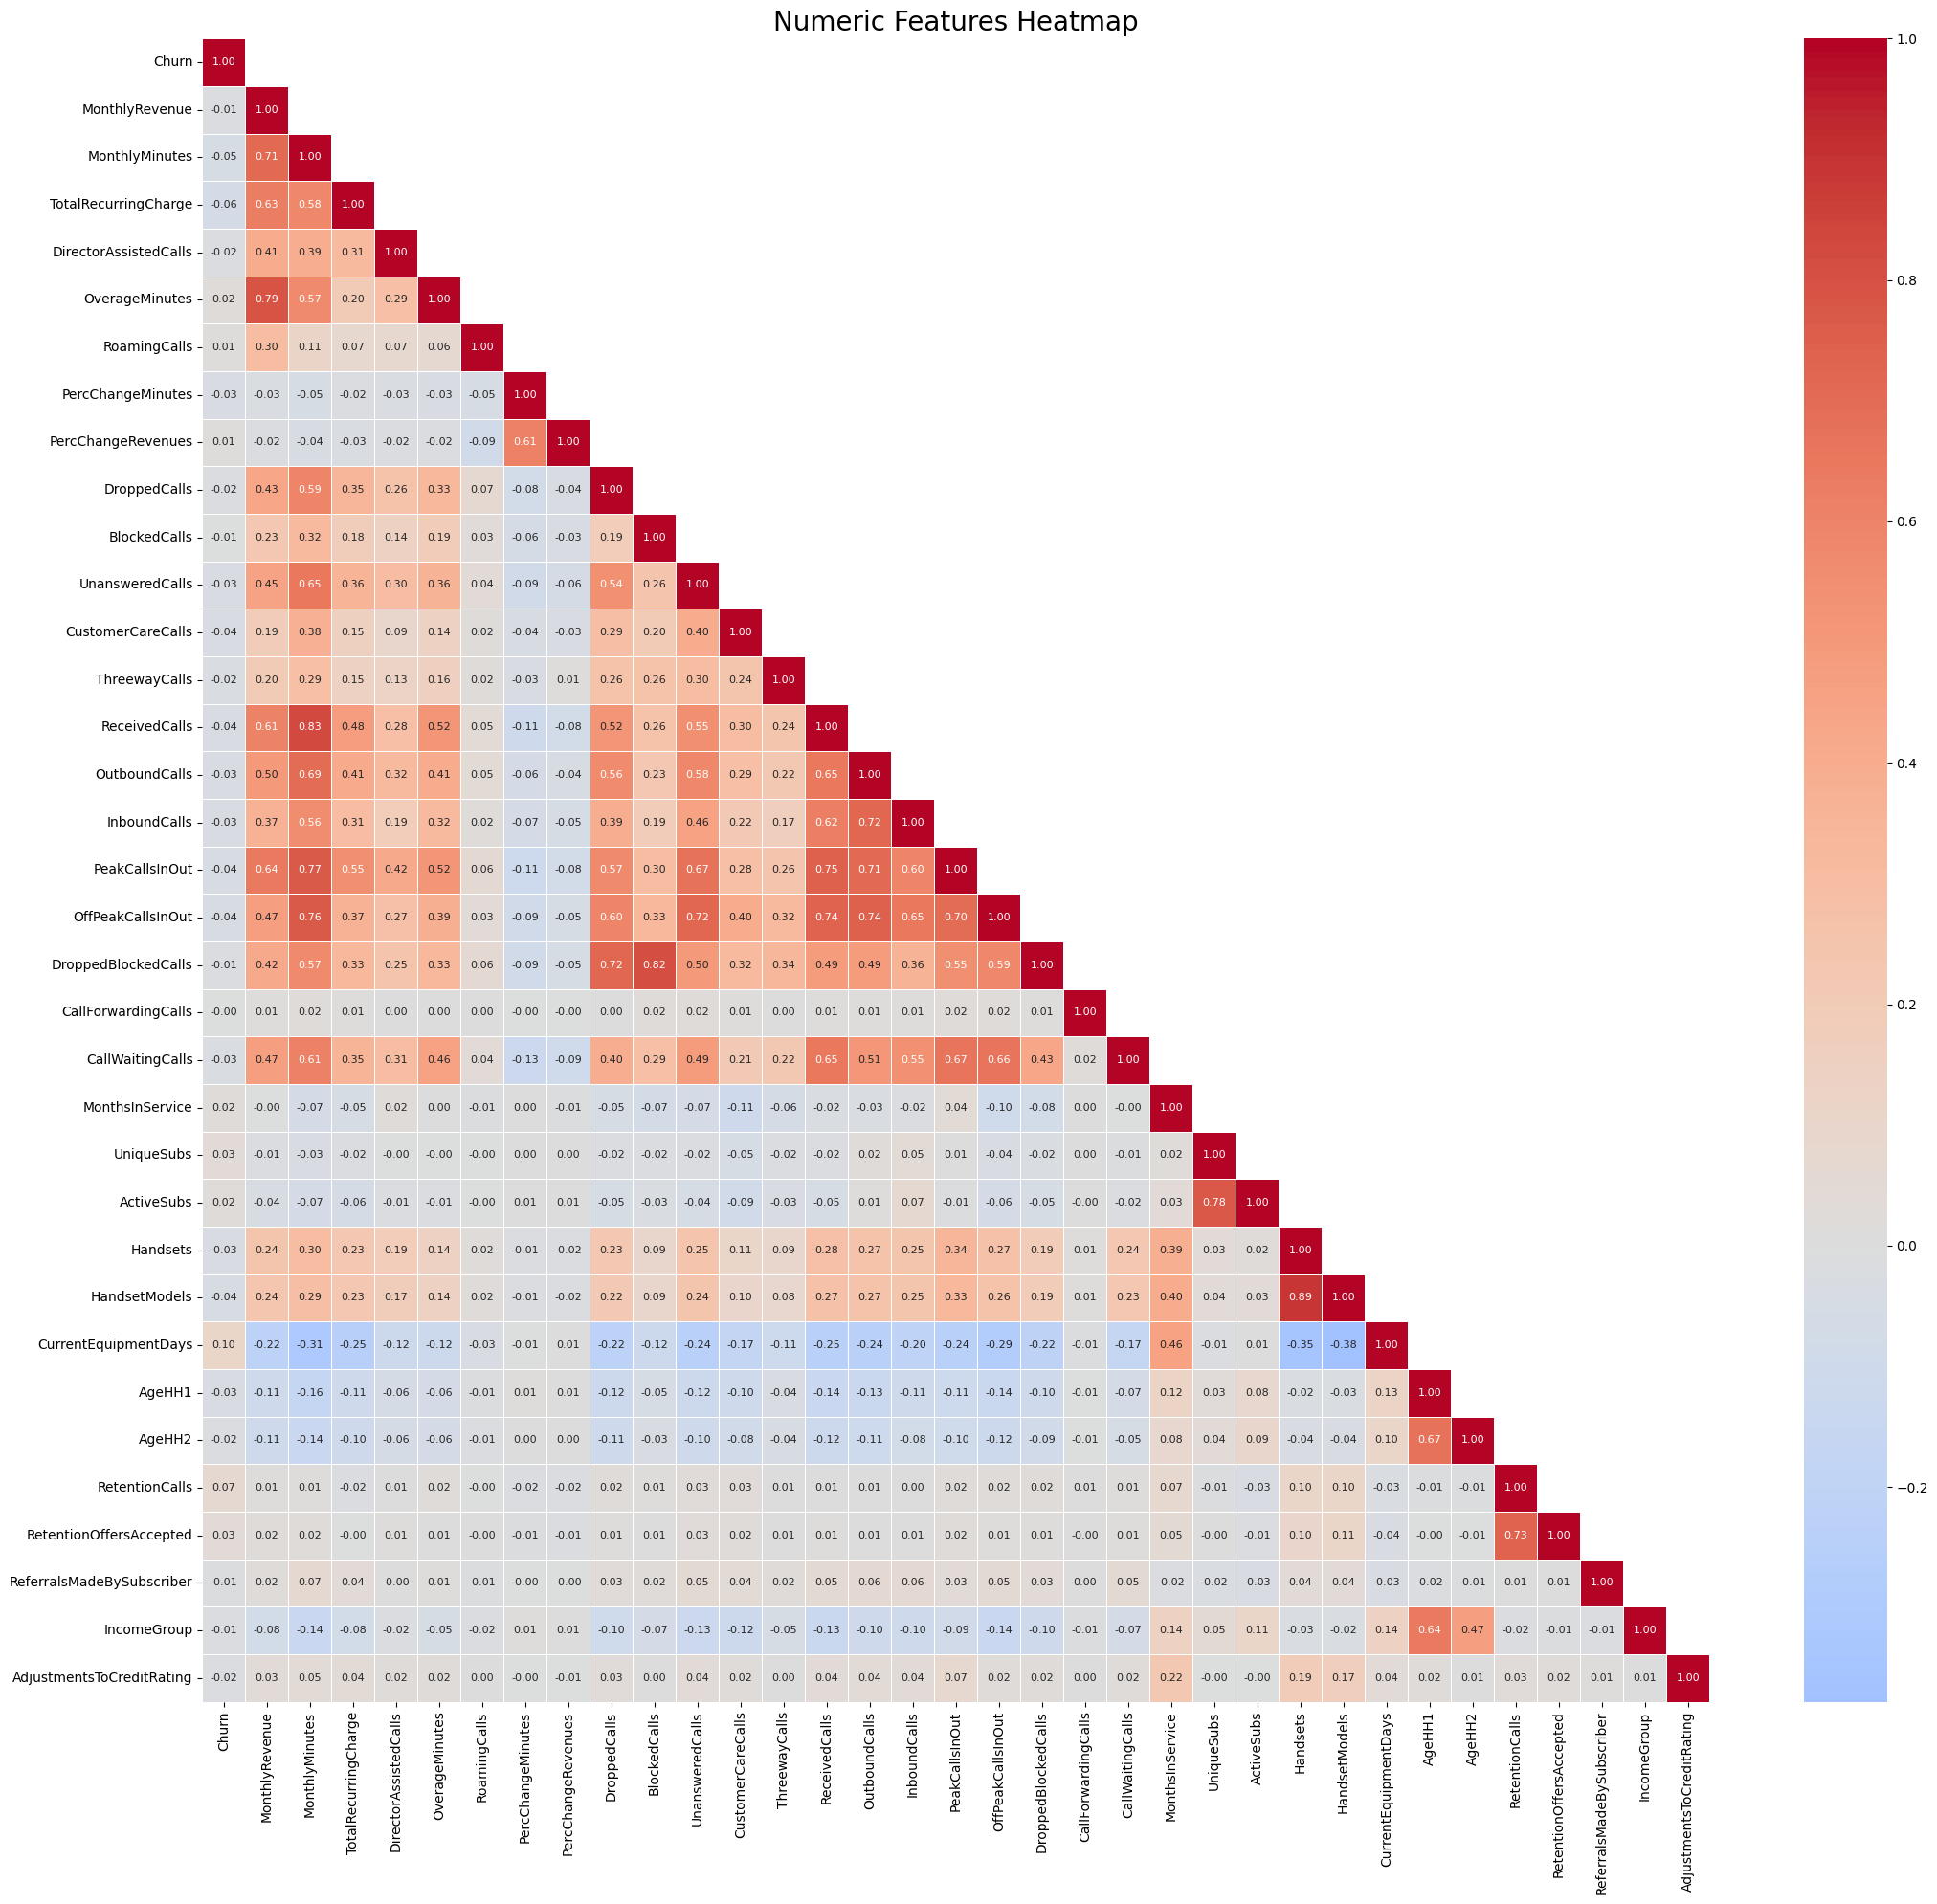

In [164]:
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(22, 20)) # 숫자가 다 보이도록 크기를 넉넉하게 지정
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, center=0, annot_kws={"size": 8}) 
plt.title('Numeric Features Heatmap', fontsize=20)
plt.tight_layout()
plt.show()

### Target인 Churn과의 상관관계

In [178]:
churn_corr = df[numeric_cols].corr()['Churn'].drop('Churn').sort_values(ascending=False)
churn_corr

CurrentEquipmentDays         0.103688
RetentionCalls               0.065299
RetentionOffersAccepted      0.034952
UniqueSubs                   0.034517
MonthsInService              0.018695
OverageMinutes               0.016455
ActiveSubs                   0.015509
PercChangeRevenues           0.011118
RoamingCalls                 0.010880
CallForwardingCalls         -0.001449
BlockedCalls                -0.005534
ReferralsMadeBySubscriber   -0.010689
MonthlyRevenue              -0.011982
IncomeGroup                 -0.012726
DroppedBlockedCalls         -0.013274
DroppedCalls                -0.015406
AdjustmentsToCreditRating   -0.017058
AgeHH2                      -0.018587
DirectorAssistedCalls       -0.019522
ThreewayCalls               -0.023857
CallWaitingCalls            -0.025657
UnansweredCalls             -0.029360
AgeHH1                      -0.029760
OutboundCalls               -0.032285
Handsets                    -0.032845
PercChangeMinutes           -0.034202
InboundCalls